# Pixelado, residuo y conexion con redes residuales

Este notebook carga una imagen local (`leonora.png`), crea una version pixelada, calcula el residuo y conecta el concepto con la idea de aprendizaje residual en ResNet.

## 1) Configurar entorno y cargar la imagen desde ruta local

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Ruta principal del proyecto (funciona si ejecutas desde notebooks/ o desde la raiz)
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

cnn_dir = project_root / "data" / "cnn_images"
preferred = cnn_dir / "leonora.png"
fallbacks = [cnn_dir / "leonora.jpg", cnn_dir / "leonora_original.png"]

if preferred.exists():
    img_path = preferred
else:
    existing = [p for p in fallbacks if p.exists()]
    if not existing:
        raise FileNotFoundError(f"No se encontro una imagen de Leonora en: {cnn_dir}")
    img_path = existing[0]

print(f"Imagen seleccionada: {img_path}")
img_pil = Image.open(img_path).convert("RGB")
print("Imagen cargada correctamente.")

Imagen seleccionada: c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\data\cnn_images\leonora.jpg
Imagen cargada correctamente.


## 2) Visualizar y normalizar la imagen original

Shape: (1945, 1960, 3) | dtype original: uint8 | dtype normalizado: float32
Min/Max normalizado: 0.000 / 0.941


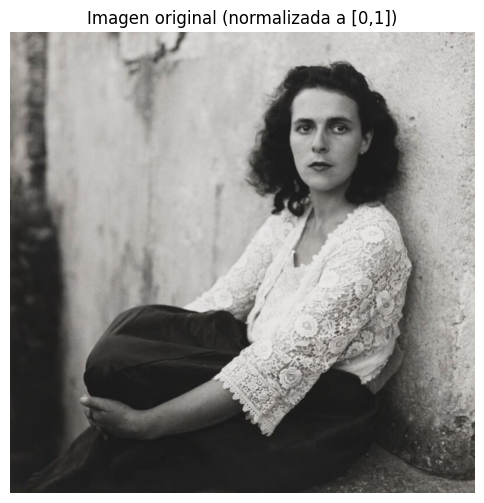

In [4]:
img_np = np.array(img_pil)
img = img_np.astype(np.float32) / 255.0

print(f"Shape: {img.shape} | dtype original: {img_np.dtype} | dtype normalizado: {img.dtype}")
print(f"Min/Max normalizado: {img.min():.3f} / {img.max():.3f}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Imagen original (normalizada a [0,1])")
plt.axis("off")
plt.show()

## 3) Generar version pixelada con remuestreo

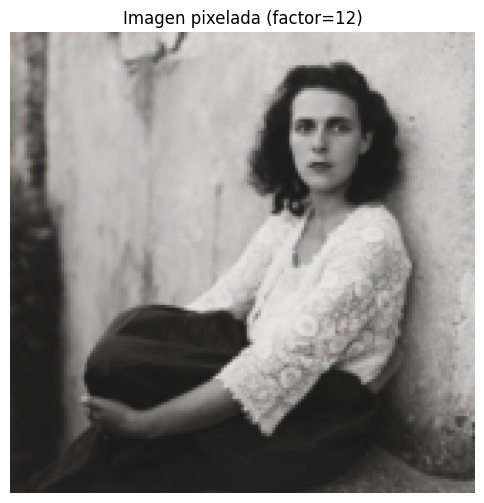

In [5]:
def pixelate_image(img_float01: np.ndarray, factor: int = 8) -> np.ndarray:
    """Pixelado por downsampling + upsampling con vecino mas cercano."""
    if factor < 1:
        raise ValueError("factor debe ser >= 1")

    h, w, _ = img_float01.shape
    w_small = max(1, w // factor)
    h_small = max(1, h // factor)

    pil = Image.fromarray((img_float01 * 255).astype(np.uint8))
    small = pil.resize((w_small, h_small), Image.Resampling.BILINEAR)
    pixel = small.resize((w, h), Image.Resampling.NEAREST)

    return np.array(pixel).astype(np.float32) / 255.0

pixel_factor = 12  # ajusta este valor para cambiar el nivel de pixelado
img_pixel = pixelate_image(img, factor=pixel_factor)

plt.figure(figsize=(6, 6))
plt.imshow(img_pixel)
plt.title(f"Imagen pixelada (factor={pixel_factor})")
plt.axis("off")
plt.show()

## 4) Calcular la imagen residual ($R = I - \hat{I}$)

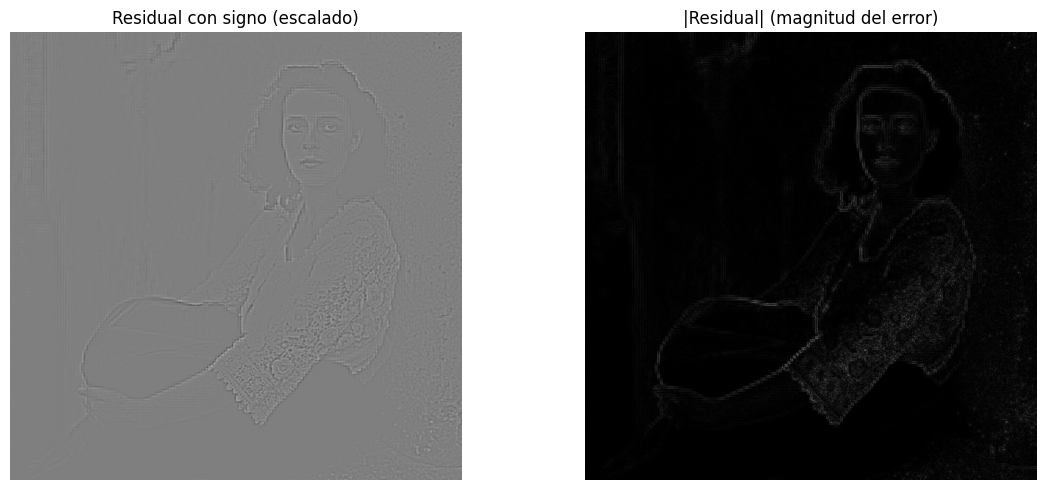

In [6]:
residual = img - img_pixel
residual_abs = np.abs(residual)

# Para visualizar el residual con signo, lo llevamos a [0,1] centrado en 0.5
residual_vis = np.clip((residual + 1.0) / 2.0, 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(residual_vis)
axes[0].set_title("Residual con signo (escalado)")
axes[0].axis("off")

axes[1].imshow(np.clip(residual_abs, 0.0, 1.0))
axes[1].set_title("|Residual| (magnitud del error)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5) Analizar el residuo con metricas ($\text{MSE}$ y energia residual)

In [7]:
def mse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean((a - b) ** 2))

def residual_energy(r: np.ndarray) -> float:
    return float(np.sqrt(np.sum(r ** 2)))  # norma L2

mse_value = mse(img, img_pixel)
energy_value = residual_energy(residual)

print(f"Factor actual: {pixel_factor}")
print(f"MSE: {mse_value:.6f}")
print(f"Energia residual (L2): {energy_value:.4f}")

print("\nComparacion al variar factor de pixelado:")
for f in [2, 4, 8, 12, 16, 24]:
    pix_f = pixelate_image(img, factor=f)
    r_f = img - pix_f
    print(f"factor={f:>2} | MSE={mse(img, pix_f):.6f} | L2={residual_energy(r_f):.4f}")

Factor actual: 12
MSE: 0.001293
Energia residual (L2): 121.5903

Comparacion al variar factor de pixelado:
factor= 2 | MSE=0.000076 | L2=29.5627
factor= 4 | MSE=0.000282 | L2=56.8273
factor= 8 | MSE=0.000799 | L2=95.5903
factor=12 | MSE=0.001293 | L2=121.5903
factor=16 | MSE=0.001759 | L2=141.8275
factor=24 | MSE=0.002599 | L2=172.3958


## 6) Comparar original, pixelada y residuo en una sola figura

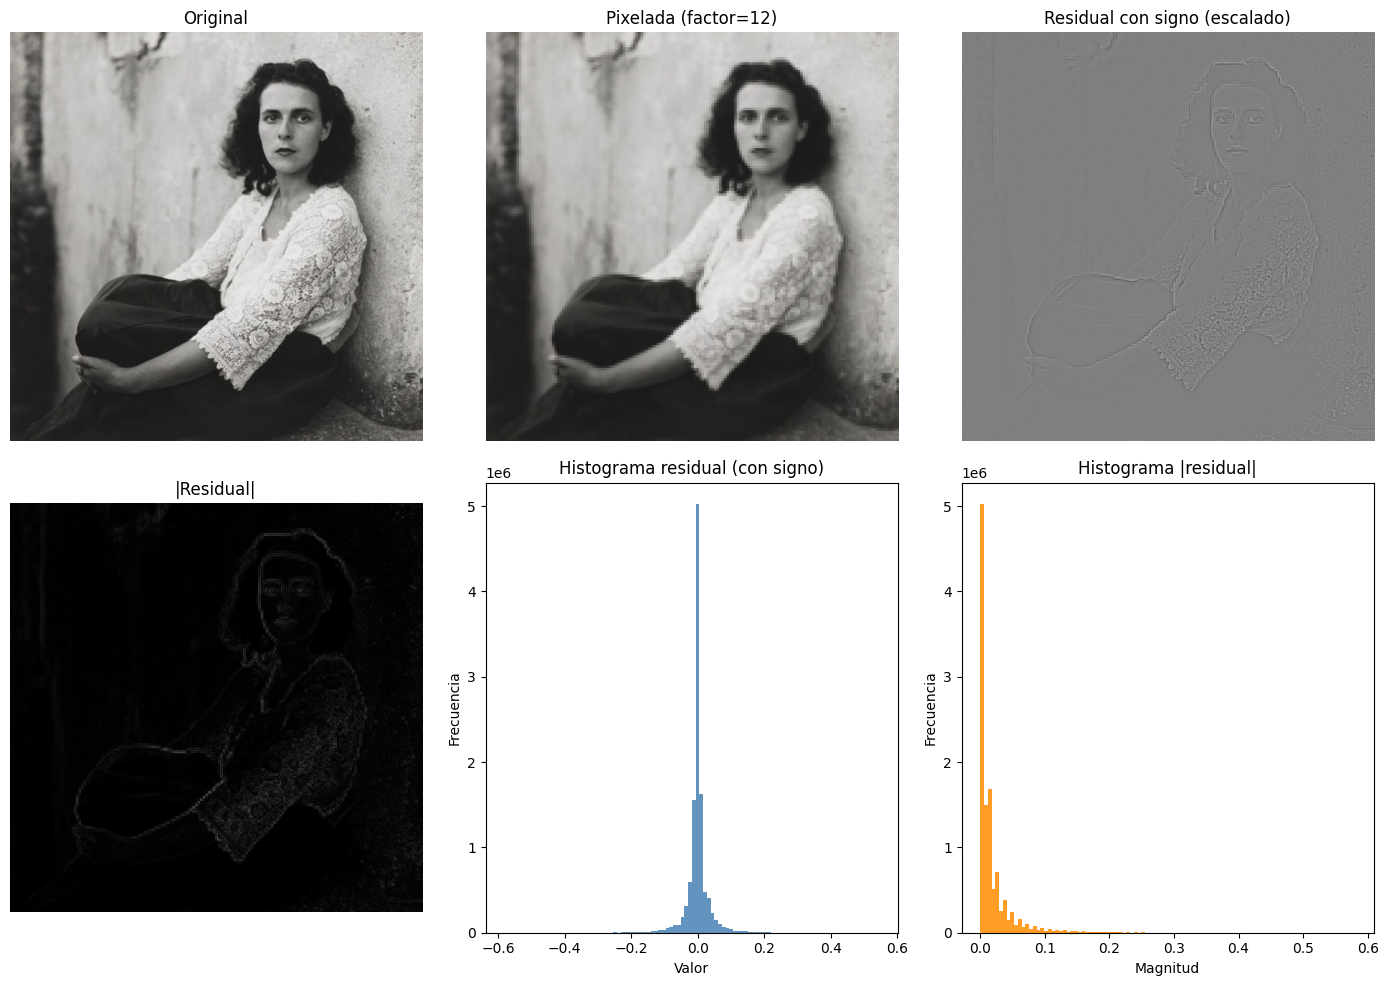

In [8]:
fig = plt.figure(figsize=(14, 10))
ax1 = plt.subplot(2, 3, 1)
ax2 = plt.subplot(2, 3, 2)
ax3 = plt.subplot(2, 3, 3)
ax4 = plt.subplot(2, 3, 4)
ax5 = plt.subplot(2, 3, 5)
ax6 = plt.subplot(2, 3, 6)

ax1.imshow(img)
ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(img_pixel)
ax2.set_title(f"Pixelada (factor={pixel_factor})")
ax2.axis("off")

ax3.imshow(residual_vis)
ax3.set_title("Residual con signo (escalado)")
ax3.axis("off")

ax4.imshow(np.clip(residual_abs, 0.0, 1.0))
ax4.set_title("|Residual|")
ax4.axis("off")

ax5.hist(residual.flatten(), bins=100, color="steelblue", alpha=0.85)
ax5.set_title("Histograma residual (con signo)")
ax5.set_xlabel("Valor")
ax5.set_ylabel("Frecuencia")

ax6.hist(residual_abs.flatten(), bins=100, color="darkorange", alpha=0.85)
ax6.set_title("Histograma |residual|")
ax6.set_xlabel("Magnitud")
ax6.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 7) Conectar el residuo con bloques de redes residuales ($y = F(x) + x$)

En este experimento, la imagen pixelada $\hat{I}$ funciona como una aproximacion burda de la imagen original $I$. El residuo es:

$$
R = I - \hat{I}
$$

Si sumamos ese residuo de vuelta a la aproximacion:

$$
\hat{I}_{\text{mejorada}} = \hat{I} + R = I
$$

Esto es analogo al principio de ResNet: en lugar de aprender directamente $H(x)$, el bloque aprende una correccion $F(x)$ y la suma a la entrada:

$$
y = x + F(x)
$$

La intuicion es que aprender la *diferencia* (correccion) suele ser mas facil que aprender toda la transformacion desde cero, especialmente en redes profundas.

MSE(original, reconstruida = pixelada + residual): 0.0000000000


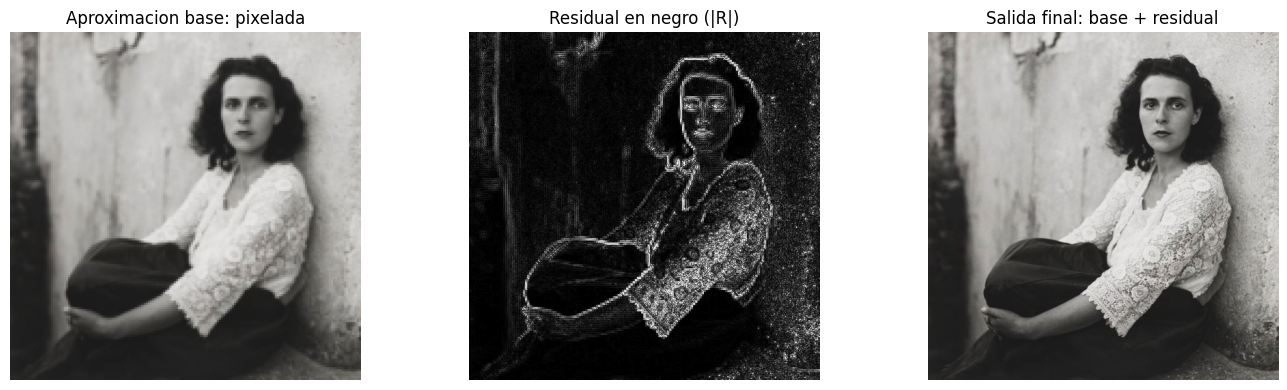

In [10]:
# Ejemplo minimo de reconstruccion residual
img_reconstructed = np.clip(img_pixel + residual, 0.0, 1.0)

recon_error = mse(img, img_reconstructed)
print(f"MSE(original, reconstruida = pixelada + residual): {recon_error:.10f}")

# Residual en negro para mejorar visibilidad del detalle
residual_gray = residual_abs.mean(axis=2)
vmax = np.percentile(residual_gray, 99) + 1e-8

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_pixel)
axes[0].set_title("Aproximacion base: pixelada")
axes[0].axis("off")

axes[1].set_facecolor("black")
axes[1].imshow(residual_gray, cmap="gray", vmin=0.0, vmax=vmax)
axes[1].set_title("Residual en negro (|R|)")
axes[1].axis("off")

axes[2].imshow(img_reconstructed)
axes[2].set_title("Salida final: base + residual")
axes[2].axis("off")

plt.tight_layout()
plt.show()